GLOBALS

In [37]:
import glob
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings


sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})
warnings.filterwarnings("ignore")

MONTH_NAMES = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}

INGEST

In [38]:
path = kagglehub.dataset_download("yusufdelikkaya/online-sales-dataset")
csv_path = glob.glob(f"{path}/*.csv")[0]
print(f"Loading: {csv_path}")

df_raw = pd.read_csv(csv_path)
print(f"Shape: {df_raw.shape}")
df_raw.head(5)

Using Colab cache for faster access to the 'online-sales-dataset' dataset.
Loading: /kaggle/input/online-sales-dataset/online_sales_dataset.csv
Shape: (49782, 17)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00,1.71,37039.0,Australia,0.470000,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00,41.25,19144.0,Spain,0.190000,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00,29.11,50472.0,Germany,0.350000,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00,76.68,96586.0,Netherlands,0.140000,paypall,11.08,Accessories,Online,Not Returned,Royal Mail,Rome,Low
4,359178,SKU_1386,USB Cable,-30,2020-01-01 04:00,-68.11,NaN,United Kingdom,1.501433,Bank Transfer,NaN,Electronics,In-store,Not Returned,FedEx,NaN,Medium


AUDIT

In [39]:
df = df_raw.copy()
print("=== Schema ===")
print(df.dtypes)
print()
print("=== Null counts ===")
null_summary = df.isnull().sum()
print(null_summary[null_summary > 0])

=== Schema ===
InvoiceNo              int64
StockCode             object
Description           object
Quantity               int64
InvoiceDate           object
UnitPrice            float64
CustomerID           float64
Country               object
Discount             float64
PaymentMethod         object
ShippingCost         float64
Category              object
SalesChannel          object
ReturnStatus          object
ShipmentProvider      object
WarehouseLocation     object
OrderPriority         object
dtype: object

=== Null counts ===
CustomerID           4978
ShippingCost         2489
WarehouseLocation    3485
dtype: int64


CLEAN

In [40]:
# Parse dates
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], infer_datetime_format=True)
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
df["Week"] = df["InvoiceDate"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

In [41]:
# Derive Revenue after discount
df["GrossRevenue"] = df["Quantity"] * df["UnitPrice"]
df["DiscountAmount"] = df["GrossRevenue"] * df["Discount"]
df["NetRevenue"] = df["GrossRevenue"] - df["DiscountAmount"] - df["ShippingCost"]
df["IsReturned"] = (df["ReturnStatus"].str.lower().str.strip() == "returned").astype(int)

In [42]:
# Drop bad rows
before = len(df)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
after = len(df)
print(f"Rows removed (zero/negative qty or price): {before - after}")
print(f"Clean dataset shape: {df.shape}")

Rows removed (zero/negative qty or price): 2489
Clean dataset shape: (47293, 26)


In [43]:
# Data Quality Summary
quality = pd.DataFrame(
    {
        "Total Rows": [len(df_raw)],
        "Clean Rows": [len(df)],
        "Null CustomerID": [df_raw["CustomerID"].isnull().sum()],
        "Returned Orders": [df["IsReturned"].sum()],
        "Return Rate (%)": [round(df["IsReturned"].mean() * 100, 2)],
        "Date Range": [
            f"{df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}"
        ],
    }
)
quality.T.rename(columns={0: "Value"})

,Value
Total Rows,49782
Clean Rows,47293
Null CustomerID,4978
Returned Orders,4646
Return Rate (%),9.82
Date Range,2020-01-01 → 2025-09-05


EDA : Revenue and Category Analysis

Revenue By Category

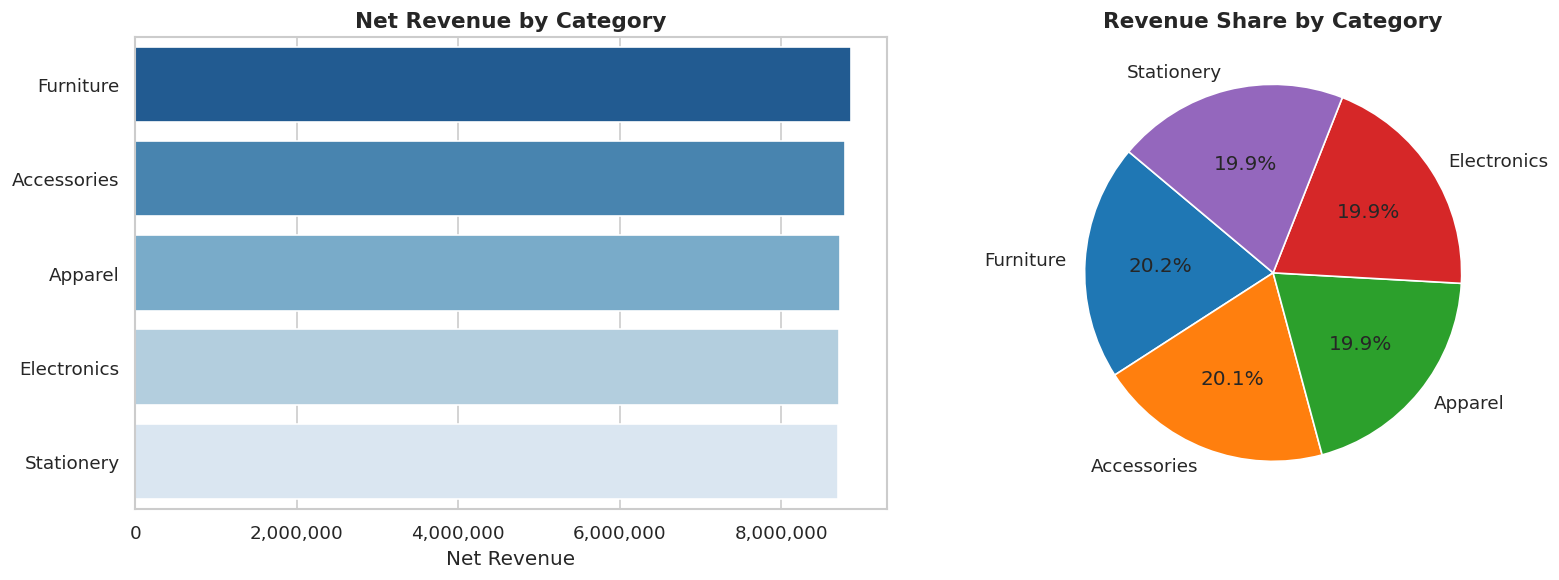

   Category   NetRevenue
  Furniture 8862106.4067
Accessories 8790453.5749
    Apparel 8728868.2130
Electronics 8719250.9810
 Stationery 8705646.5222


In [44]:
cat_rev = (
    df.groupby("Category")["NetRevenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(data=cat_rev, x="NetRevenue", y="Category", ax=axes[0], palette="Blues_r")
axes[0].set_title("Net Revenue by Category", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Net Revenue")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Revenue Share Pie chart
axes[1].pie(
    cat_rev["NetRevenue"],
    labels=cat_rev["Category"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("tab10", len(cat_rev)),
)
axes[1].set_title("Revenue Share by Category", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("/content/insight1_category_revenue.png", bbox_inches="tight")
plt.show()
print(cat_rev.to_string(index=False))

Insight: Synthetic Dataset. Uniformly distributed revenues for categories. Not worth talking about.

Monthly Revenue Trend

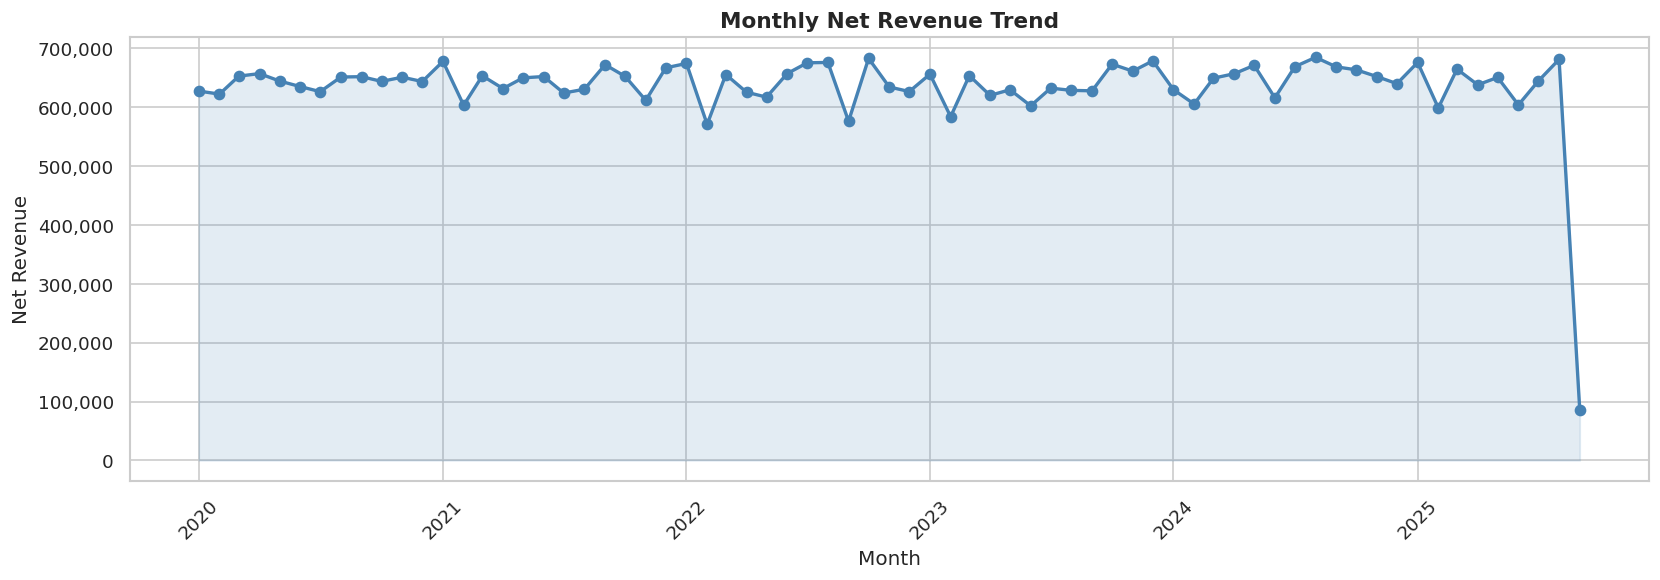

In [45]:
monthly = df.groupby("YearMonth")["NetRevenue"].sum().reset_index()
monthly["YearMonth_dt"] = monthly["YearMonth"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    monthly["YearMonth_dt"],
    monthly["NetRevenue"],
    marker="o",
    linewidth=2,
    color="steelblue",
)
ax.fill_between(
    monthly["YearMonth_dt"], monthly["NetRevenue"], alpha=0.15, color="steelblue"
)
ax.set_title("Monthly Net Revenue Trend", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Net Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/insight1_monthly_trend.png", bbox_inches="tight")
plt.show()

Insight: Sharp drop at the end is because transactions aren't available for the entire month. Still nothing worth explaining.

Revenue & Units Sold by Category Over Time

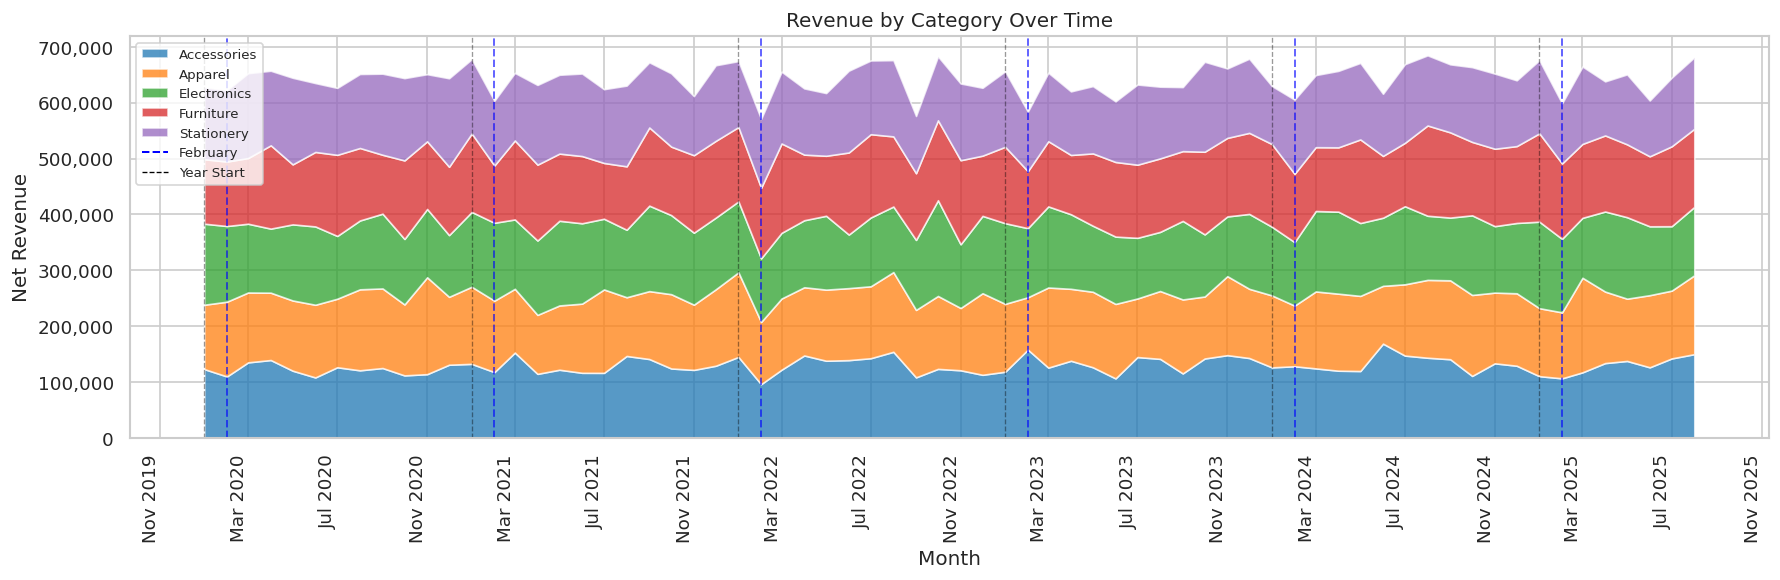

In [46]:
# Drop incomplete final month
df_filtered = df[df["YearMonth"] < df["YearMonth"].max()]

cat_rev = (
    df_filtered.groupby(["YearMonth", "Category"])["NetRevenue"]
    .sum()
    .unstack(fill_value=0)
)
cat_rev.index = cat_rev.index.to_timestamp()

colors = sns.color_palette("tab10", len(cat_rev.columns))

fig, ax = plt.subplots(figsize=(15, 5))
ax.stackplot(
    cat_rev.index, cat_rev.T.values, labels=cat_rev.columns, alpha=0.75, colors=colors
)
ax.set(title="Revenue by Category Over Time", xlabel="Month", ylabel="Net Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Year markers
for year in range(2020, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="black", lw=0.8, ls="--", alpha=0.4)

# February markers
for year in range(2020, 2026):
    ax.axvline(pd.Timestamp(f"{year}-02-01"), color="blue", lw=1.2, ls="--", alpha=0.6)

from matplotlib.lines import Line2D

extra_legend = [
    Line2D([0], [0], color="blue", lw=1.2, ls="--", label="February"),
    Line2D([0], [0], color="black", lw=0.8, ls="--", label="Year Start"),
]
ax.legend(
    handles=ax.get_legend_handles_labels()[0] + extra_legend,
    labels=ax.get_legend_handles_labels()[1] + ["February", "Year Start"],
    loc="upper left",
    fontsize=8,
)

plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.savefig("/content/insight_revenue_trend.png", bbox_inches="tight")
plt.show()

Insight: Revenue is evenly distributed across categories over time, but we can see some seasonal patterns. There is clear dip at in revenue at the start of every year, between January and March. Why is there no growth?

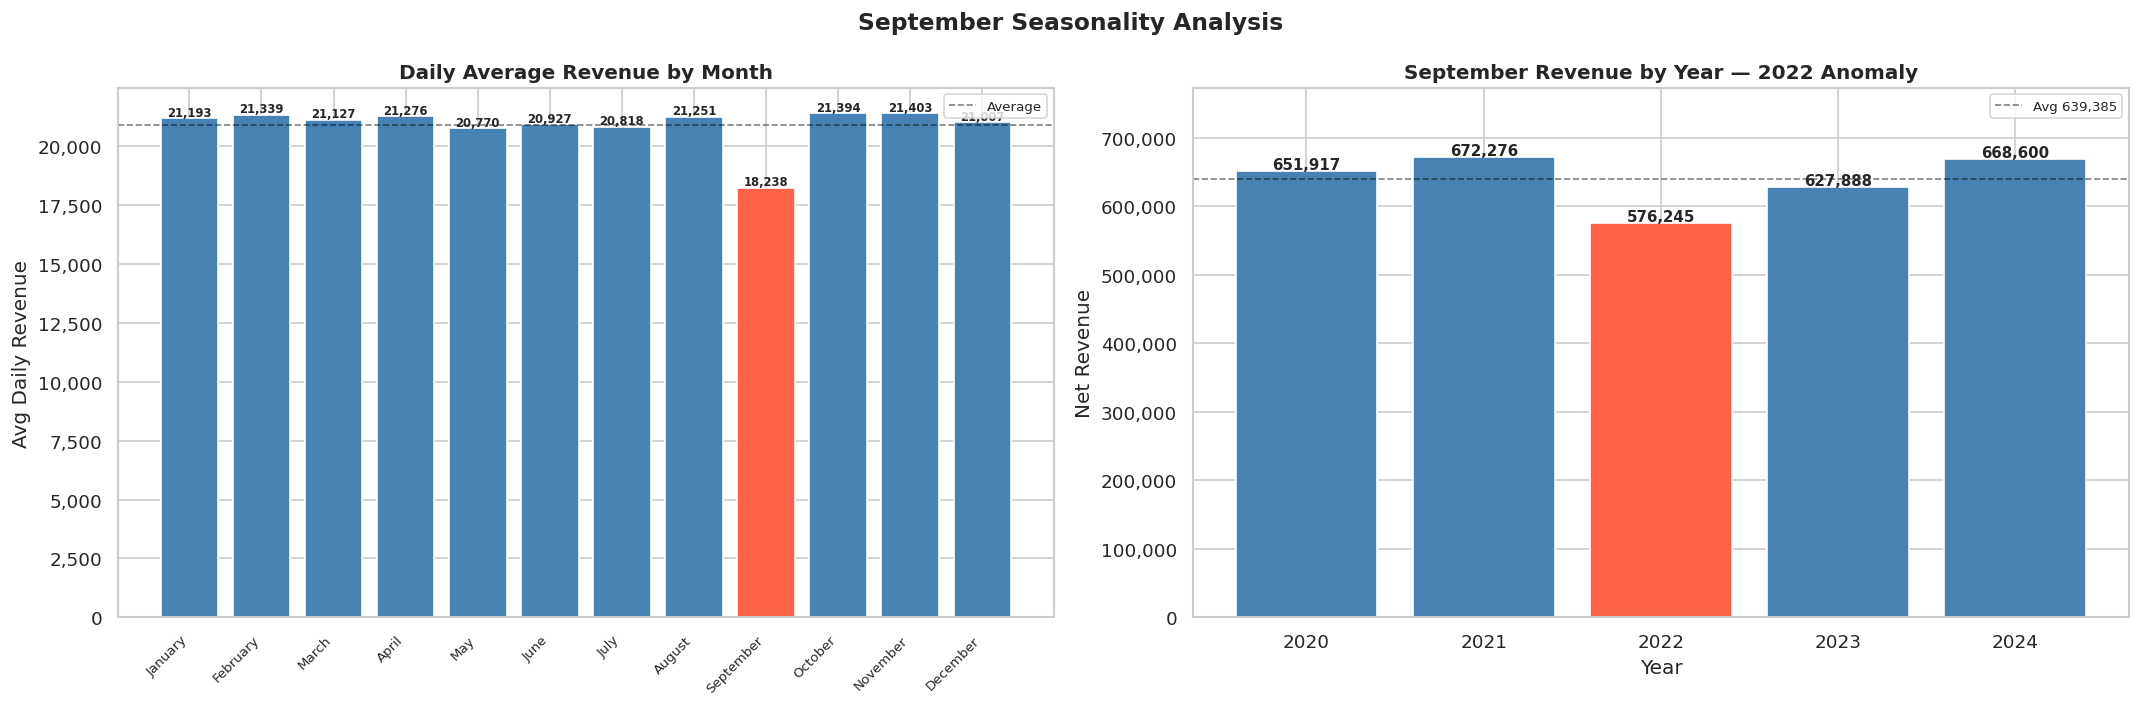

In [47]:
# Daily Average Revenue + September Anomaly
import calendar

monthly_avg = (
    df.groupby(["Year", "Month"])["NetRevenue"]
    .sum()
    .groupby("Month")
    .mean()
    .round(0)
    .astype(int)
    .reset_index()
    .rename(columns={"NetRevenue": "AvgMonthlyRevenue"})
)
monthly_avg["Days"] = monthly_avg["Month"].apply(
    lambda m: calendar.monthrange(2023, m)[1]
)
monthly_avg["DailyAvgRevenue"] = (
    (monthly_avg["AvgMonthlyRevenue"] / monthly_avg["Days"]).round(0).astype(int)
)
monthly_avg["MonthName"] = monthly_avg["Month"].map(MONTH_NAMES)

sep_revenue = (
    df[df["Month"] == 9]
    .groupby("Year")["NetRevenue"]
    .sum()
    .round(0)
    .astype(int)
    .reset_index()
)
sep_revenue = sep_revenue[sep_revenue["Year"] < 2025]
avg_sep = sep_revenue["NetRevenue"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: Daily Average Revenue by Month
colors_month = ["tomato" if m == 9 else "steelblue" for m in monthly_avg["Month"]]
bars = ax1.bar(
    monthly_avg["MonthName"], monthly_avg["DailyAvgRevenue"], color=colors_month
)
ax1.axhline(
    monthly_avg["DailyAvgRevenue"].mean(),
    color="black",
    lw=1,
    ls="--",
    alpha=0.5,
    label="Average",
)
for bar, val in zip(bars, monthly_avg["DailyAvgRevenue"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,}",
        ha="center",
        fontsize=7,
        fontweight="bold",
    )
ax1.set_title("Daily Average Revenue by Month", fontweight="bold", fontsize=12)
ax1.set_ylabel("Avg Daily Revenue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.legend(fontsize=8)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Right: September Revenue by Year
colors_sep = ["tomato" if y == 2022 else "steelblue" for y in sep_revenue["Year"]]
bars = ax2.bar(sep_revenue["Year"], sep_revenue["NetRevenue"], color=colors_sep)
for bar, val in zip(bars, sep_revenue["NetRevenue"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f"{val:,}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
ax2.axhline(
    avg_sep, color="black", lw=1, ls="--", alpha=0.5, label=f"Avg {avg_sep:,.0f}"
)
ax2.set_title(
    "September Revenue by Year — 2022 Anomaly", fontweight="bold", fontsize=12
)
ax2.set_xlabel("Year")
ax2.set_ylabel("Net Revenue")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.set_ylim(0, sep_revenue["NetRevenue"].max() * 1.15)
ax2.legend(fontsize=8)

plt.suptitle("September Seasonality Analysis", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("/content/insight_sep_merged.png", bbox_inches="tight")
plt.show()

Insight: This shows that the dip we saw in February was just a calender event, September is the real dip and something happened in the year 2022 that is bringing the overall average down. ANOMALY

Anomaly Detection Model

In [48]:
# Prepare Monthly Features
import calendar
from sklearn.ensemble import IsolationForest

monthly_features = (
    df.groupby(["Year", "Month"])
    .agg(
        TotalRevenue=("NetRevenue", "sum"),
        OrderCount=("InvoiceNo", "nunique"),
        AvgOrderValue=("NetRevenue", "mean"),
        UniqueCustomers=("CustomerID", "nunique"),
        AvgDiscount=("Discount", "mean"),
        AvgUnitPrice=("UnitPrice", "mean"),
    )
    .reset_index()
    .sort_values(["Year", "Month"])
)

# Drop incomplete months
monthly_features = monthly_features[
    ~((monthly_features["Year"] == 2025) & (monthly_features["Month"] >= 8))
]

# Normalize for month length
monthly_features["DaysInMonth"] = monthly_features.apply(
    lambda row: calendar.monthrange(int(row["Year"]), int(row["Month"]))[1], axis=1
)
monthly_features["DailyRevenue"] = (
    monthly_features["TotalRevenue"] / monthly_features["DaysInMonth"]
).round(0)
monthly_features["Date"] = pd.to_datetime(
    monthly_features[["Year", "Month"]].assign(day=1)
)
monthly_features["DailyOrders"] = (
    monthly_features["OrderCount"] / monthly_features["DaysInMonth"]
).round(2)
monthly_features["DailyCustomers"] = (
    monthly_features["UniqueCustomers"] / monthly_features["DaysInMonth"]
).round(2)

print(f"Months in dataset: {len(monthly_features)}")
monthly_features.head()

Months in dataset: 67


,Year,Month,TotalRevenue,OrderCount,AvgOrderValue,UniqueCustomers,AvgDiscount,AvgUnitPrice,DaysInMonth,DailyRevenue,Date,DailyOrders,DailyCustomers
0,2020,1,627433.5723,714,878.758505,668,0.253824,48.599944,31,20240.0,2020-01-01,23.03,21.55
1,2020,2,622314.3085,664,937.220344,631,0.243404,51.162545,29,21459.0,2020-02-01,22.90,21.76
2,2020,3,652829.9936,708,922.076262,679,0.252556,49.251398,31,21059.0,2020-03-01,22.84,21.90
3,2020,4,657150.8663,690,952.392560,653,0.253435,49.956754,30,21905.0,2020-04-01,23.00,21.77
4,2020,5,644558.3449,702,918.174280,664,0.250427,50.204758,31,20792.0,2020-05-01,22.65,21.42


In [49]:
# Train Isolation Forest
FEATURES = [
    "DailyRevenue",
    "DailyOrders",
    "DailyCustomers",
    "AvgOrderValue",
    "AvgDiscount",
    "AvgUnitPrice",
    "Month",
]

X = monthly_features[FEATURES]

iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso.fit(X)

monthly_features["AnomalyScore"] = iso.decision_function(X)
monthly_features["IsAnomaly"] = iso.predict(X)
monthly_features["IsAnomaly"] = monthly_features["IsAnomaly"].map({1: 0, -1: 1})

avg_rev = monthly_features["TotalRevenue"].mean()
monthly_features["IsAnomaly"] = monthly_features.apply(
    lambda row: 1 if row["IsAnomaly"] == 1 and row["TotalRevenue"] < avg_rev else 0,
    axis=1,
)

anomalies = monthly_features[monthly_features["IsAnomaly"] == 1]
print(f"Anomalies detected: {len(anomalies)}")
print(
    anomalies[["Year", "Month", "TotalRevenue", "AnomalyScore"]].to_string(index=False)
)

Anomalies detected: 4
 Year  Month  TotalRevenue  AnomalyScore
 2021     11   611726.6550     -0.030742
 2022      9   576245.4559     -0.076736
 2025      2   598858.8381     -0.042194
 2025      6   603944.2774     -0.021066


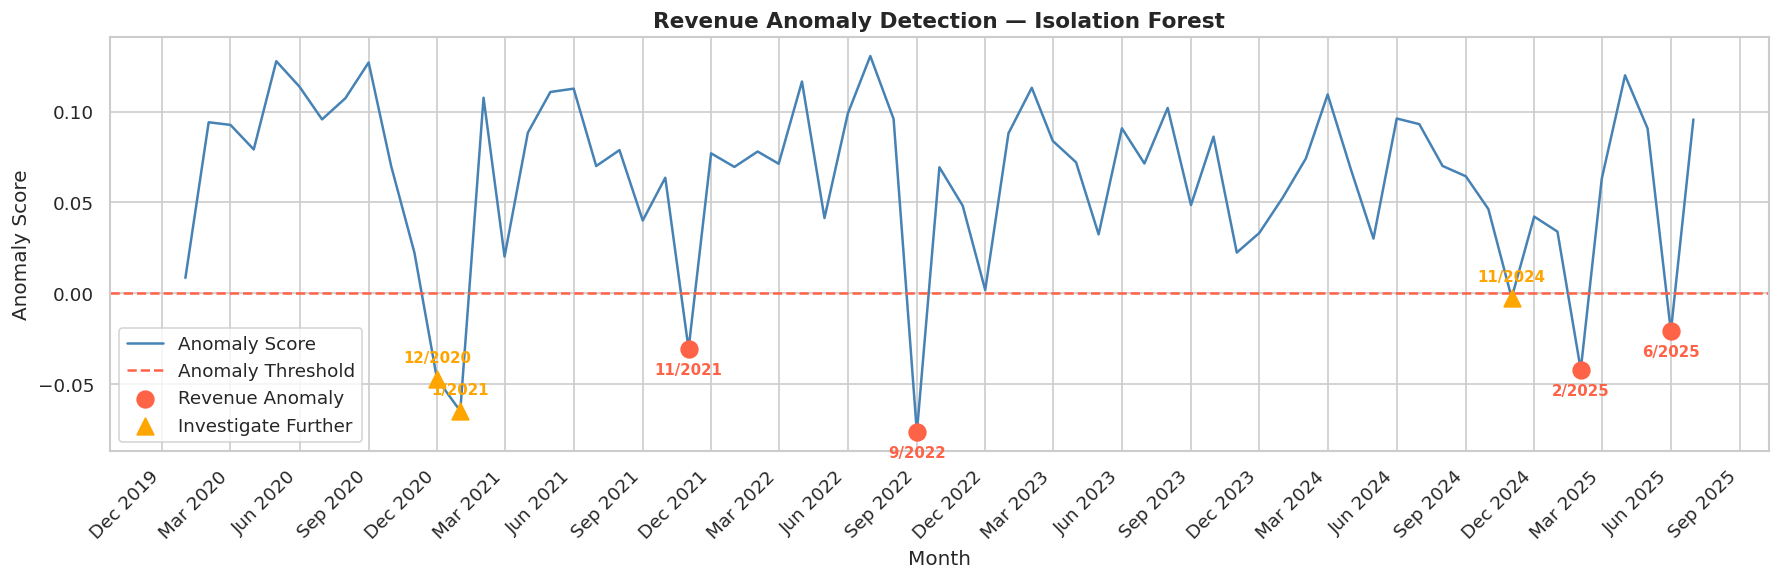

=== Revenue Anomalies (Red) ===
 Year  Month  TotalRevenue  DailyRevenue  AnomalyScore
 2021     11   611726.6550       20391.0     -0.030742
 2022      9   576245.4559       19208.0     -0.076736
 2025      2   598858.8381       21388.0     -0.042194
 2025      6   603944.2774       20131.0     -0.021066

=== Pattern Anomalies — Investigate Further (Orange) ===
 Year  Month  TotalRevenue  DailyRevenue  AnomalyScore
 2020     12   643674.6960       20764.0     -0.047218
 2021      1   677912.3974       21868.0     -0.064936
 2024     11   652050.2727       21735.0     -0.002570


In [50]:
monthly_features["IsRevenueAnomaly"] = monthly_features.apply(
    lambda row: 1 if row["AnomalyScore"] < 0 and row["TotalRevenue"] < avg_rev else 0,
    axis=1,
)
monthly_features["IsPatternAnomaly"] = monthly_features.apply(
    lambda row: 1 if row["AnomalyScore"] < 0 and row["TotalRevenue"] >= avg_rev else 0,
    axis=1,
)

revenue_anomalies = monthly_features[monthly_features["IsRevenueAnomaly"] == 1]
pattern_anomalies = monthly_features[monthly_features["IsPatternAnomaly"] == 1]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    monthly_features["Date"],
    monthly_features["AnomalyScore"],
    color="steelblue",
    linewidth=1.5,
    label="Anomaly Score",
)
ax.axhline(0, color="tomato", lw=1.5, ls="--", label="Anomaly Threshold")

# Red dots — revenue anomalies
ax.scatter(
    revenue_anomalies["Date"],
    revenue_anomalies["AnomalyScore"],
    color="tomato",
    s=100,
    zorder=5,
    label="Revenue Anomaly",
)
for _, row in revenue_anomalies.iterrows():
    ax.annotate(
        f"{row['Month']}/{row['Year']}",
        xy=(row["Date"], row["AnomalyScore"]),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="tomato",
        fontweight="bold",
    )

# Orange triangles — pattern anomalies
ax.scatter(
    pattern_anomalies["Date"],
    pattern_anomalies["AnomalyScore"],
    color="orange",
    s=100,
    zorder=5,
    marker="^",
    label="Investigate Further",
)
for _, row in pattern_anomalies.iterrows():
    ax.annotate(
        f"{row['Month']}/{row['Year']}",
        xy=(row["Date"], row["AnomalyScore"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="orange",
        fontweight="bold",
    )

ax.set_title(
    "Revenue Anomaly Detection — Isolation Forest", fontweight="bold", fontsize=13
)
ax.set_ylabel("Anomaly Score")
ax.set_xlabel("Month")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/ml_anomaly_detection.png", bbox_inches="tight")
plt.show()

print("=== Revenue Anomalies (Red) ===")
print(
    revenue_anomalies[
        ["Year", "Month", "TotalRevenue", "DailyRevenue", "AnomalyScore"]
    ].to_string(index=False)
)
print("\n=== Pattern Anomalies — Investigate Further (Orange) ===")
print(
    pattern_anomalies[
        ["Year", "Month", "TotalRevenue", "DailyRevenue", "AnomalyScore"]
    ].to_string(index=False)
)

In [51]:
# Anomaly Report
avg_revenue = monthly_features["TotalRevenue"].mean()

anomaly_report = anomalies[
    ["Year", "Month", "TotalRevenue", "OrderCount", "AvgOrderValue", "AnomalyScore"]
].copy()
anomaly_report["RevenueVsAvg"] = (
    (anomaly_report["TotalRevenue"] - avg_revenue) / avg_revenue * 100
).round(1)
anomaly_report["MonthName"] = anomaly_report["Month"].map(MONTH_NAMES)
anomaly_report = anomaly_report.sort_values("AnomalyScore")

print("=== Anomaly Report ===")
print(f"Average monthly revenue: {avg_revenue:,.0f}")
print()
print(
    anomaly_report[
        ["MonthName", "Year", "TotalRevenue", "RevenueVsAvg", "AnomalyScore"]
    ].to_string(index=False)
)

=== Anomaly Report ===
Average monthly revenue: 642,375

MonthName  Year  TotalRevenue  RevenueVsAvg  AnomalyScore
September  2022   576245.4559         -10.3     -0.076736
 February  2025   598858.8381          -6.8     -0.042194
 November  2021   611726.6550          -4.8     -0.030742
     June  2025   603944.2774          -6.0     -0.021066


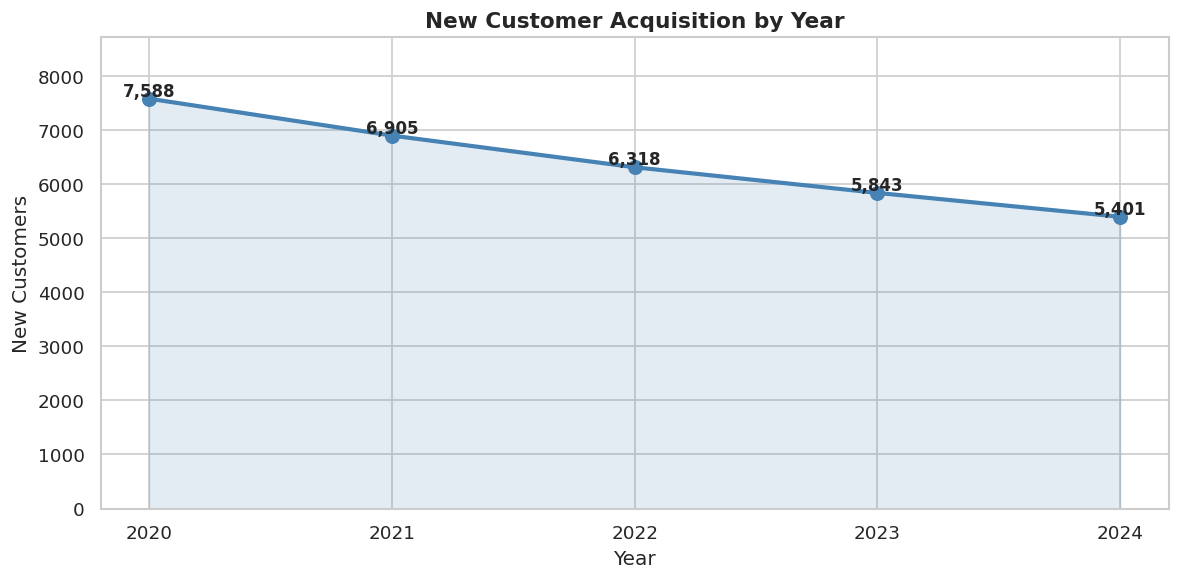

In [52]:
# New Customer Acquisition by Year
first_purchase = (
    df.groupby("CustomerID")["InvoiceDate"]
    .min()
    .dt.year.value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"InvoiceDate": "Year", "count": "NewCustomers"})
)

first_purchase = first_purchase[first_purchase["Year"] < 2025]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    first_purchase["Year"],
    first_purchase["NewCustomers"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
    markersize=8,
)
ax.fill_between(
    first_purchase["Year"],
    first_purchase["NewCustomers"],
    alpha=0.15,
    color="steelblue",
)

for x, y in zip(first_purchase["Year"], first_purchase["NewCustomers"]):
    ax.text(x, y + 50, f"{y:,}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("New Customer Acquisition by Year", fontweight="bold", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("New Customers")
ax.set_ylim(0, first_purchase["NewCustomers"].max() * 1.15)
ax.set_xticks(first_purchase["Year"])
plt.tight_layout()
plt.savefig("/content/insight_new_customers.png", bbox_inches="tight")
plt.show()

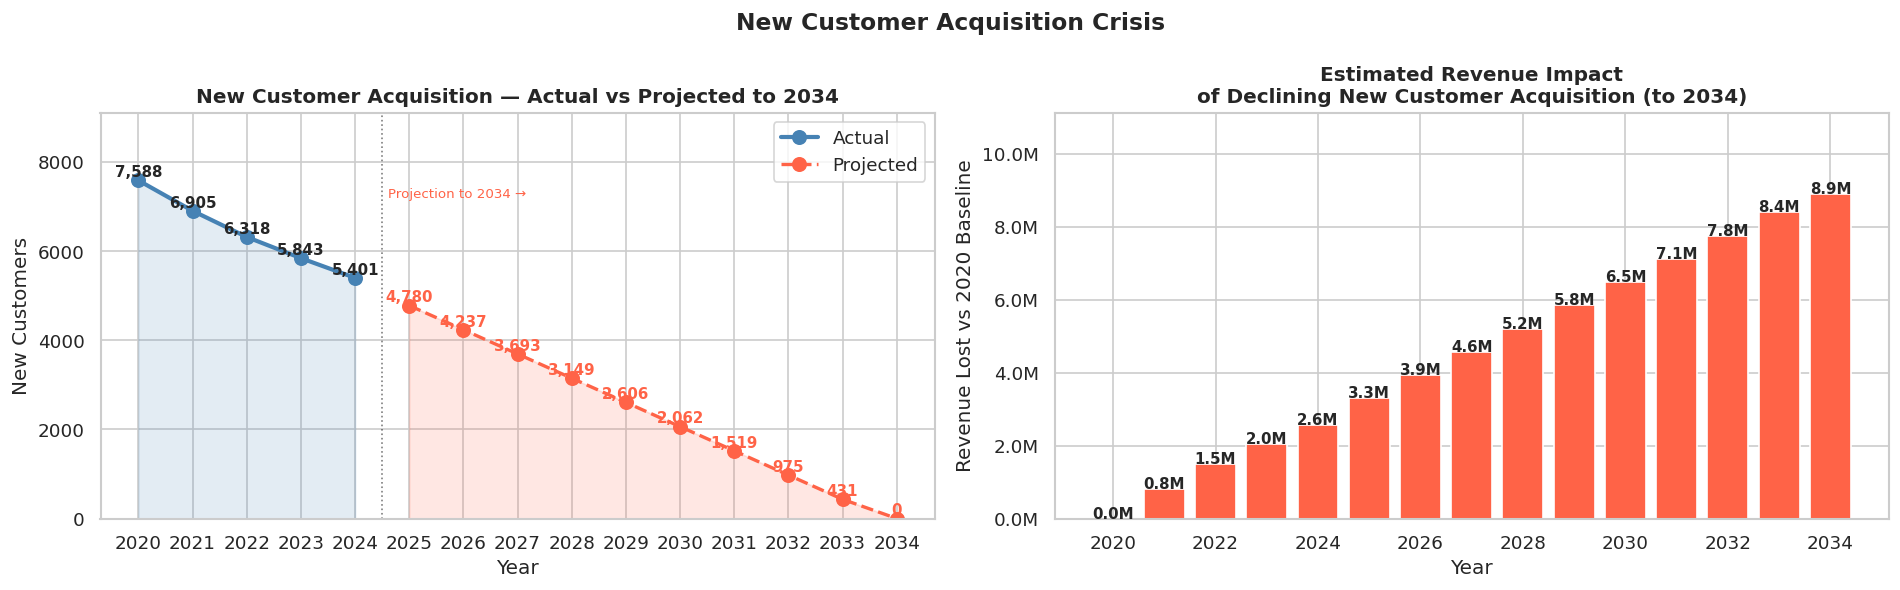

Avg revenue per customer lifetime: 1,174
Projected new customers in 2034: 0


In [53]:
from sklearn.linear_model import LinearRegression

first_purchase = (
    df.groupby("CustomerID")["InvoiceDate"]
    .min()
    .dt.year.value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"InvoiceDate": "Year", "count": "NewCustomers"})
)

first_purchase = first_purchase[first_purchase["Year"] < 2025]

# Fit linear trend
X = first_purchase["Year"].values.reshape(-1, 1)
y = first_purchase["NewCustomers"].values
reg = LinearRegression().fit(X, y)

# Project through 2034
projection_years = np.arange(2025, 2035)
future_years = projection_years.reshape(-1, 1)

projected = reg.predict(future_years)
projected = np.maximum(projected, 0).round().astype(int)

projected_df = pd.DataFrame({"Year": projection_years, "NewCustomers": projected})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Actual + Projected trend
axes[0].plot(
    first_purchase["Year"],
    first_purchase["NewCustomers"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
    markersize=8,
    label="Actual",
)

axes[0].fill_between(
    first_purchase["Year"],
    first_purchase["NewCustomers"],
    alpha=0.15,
    color="steelblue",
)

axes[0].plot(
    projected_df["Year"],
    projected_df["NewCustomers"],
    marker="o",
    linewidth=2,
    color="tomato",
    linestyle="--",
    markersize=8,
    label="Projected",
)

axes[0].fill_between(
    projected_df["Year"], projected_df["NewCustomers"], alpha=0.15, color="tomato"
)

for x, y_val in zip(first_purchase["Year"], first_purchase["NewCustomers"]):
    axes[0].text(
        x, y_val + 80, f"{y_val:,}", ha="center", fontsize=9, fontweight="bold"
    )

for x, y_val in zip(projected_df["Year"], projected_df["NewCustomers"]):
    axes[0].text(
        x,
        y_val + 80,
        f"{y_val:,}",
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="tomato",
    )

axes[0].axvline(x=2024.5, color="black", lw=1, ls=":", alpha=0.5)

axes[0].text(
    2024.6,
    first_purchase["NewCustomers"].max() * 0.95,
    "Projection to 2034 →",
    fontsize=8,
    color="tomato",
)

axes[0].set_title(
    "New Customer Acquisition — Actual vs Projected to 2034",
    fontweight="bold",
    fontsize=12,
)

axes[0].set_ylabel("New Customers")
axes[0].set_xlabel("Year")

axes[0].set_ylim(
    0,
    max(first_purchase["NewCustomers"].max(), projected_df["NewCustomers"].max()) * 1.2,
)

axes[0].set_xticks(sorted(set(first_purchase["Year"]).union(projected_df["Year"])))

axes[0].legend()

# Right: Revenue impact (extended to 2034)

avg_customer_revenue = df.groupby("CustomerID")["NetRevenue"].sum().mean()

# Extend years to include projections
all_years = np.concatenate([first_purchase["Year"].values, projection_years])

# Combine actual + projected customers
all_customers = np.concatenate(
    [first_purchase["NewCustomers"].values, projected_df["NewCustomers"].values]
)

baseline = all_customers[0]

lost_vs_baseline = (baseline - all_customers) * avg_customer_revenue

lost_customers_df = pd.DataFrame({"Year": all_years, "LostVs2020": lost_vs_baseline})

axes[1].bar(
    lost_customers_df["Year"],
    lost_customers_df["LostVs2020"],
    color=[
        "steelblue" if year == first_purchase["Year"].iloc[0] else "tomato"
        for year in lost_customers_df["Year"]
    ],
)

for bar, val in zip(axes[1].patches, lost_customers_df["LostVs2020"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10000,
        f"{val/1e6:.1f}M",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

axes[1].set_title(
    "Estimated Revenue Impact\nof Declining New Customer Acquisition (to 2034)",
    fontweight="bold",
    fontsize=12,
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Revenue Lost vs 2020 Baseline")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].set_ylim(0, lost_customers_df["LostVs2020"].max() * 1.25)

plt.suptitle("New Customer Acquisition Crisis", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.savefig("/content/insight_customer_acquisition.png", bbox_inches="tight")
plt.show()

print(f"Avg revenue per customer lifetime: {avg_customer_revenue:,.0f}")
print(f'Projected new customers in 2034: {projected_df.iloc[-1]["NewCustomers"]:,}')


In [54]:
# Fit linear trend
X = first_purchase["Year"].values.reshape(-1, 1)
y = first_purchase["NewCustomers"].values
reg = LinearRegression().fit(X, y)

slope = reg.coef_[0]
intercept = reg.intercept_

# Estimate year when new customers reach zero
zero_year = int(np.ceil(-intercept / slope))

# Only project if trend is declining
if slope < 0:
    projection_years = np.arange(2025, zero_year + 1)
else:
    projection_years = np.arange(2025, 2031)  # fallback

future_years = projection_years.reshape(-1, 1)

projected = reg.predict(future_years)

# Prevent negative customer counts
projected = np.maximum(projected, 0).round().astype(int)

projected_df = pd.DataFrame({"Year": projection_years, "NewCustomers": projected})

print(f"Slope: {slope:.2f} customers/year")
print(f"Projected customer acquisition reaches zero around {zero_year}")


Slope: -543.60 customers/year
Projected customer acquisition reaches zero around 2034


Insight: New customers are declining at a alarming rate, this is the reason for stagnation. Dataset lacks the data needed to find out why so business must investigate or provide more data. Using machine learning we project the decline in new customer and find revenue loss.

EDA: Discount And Margin Impact

Discount Buckets

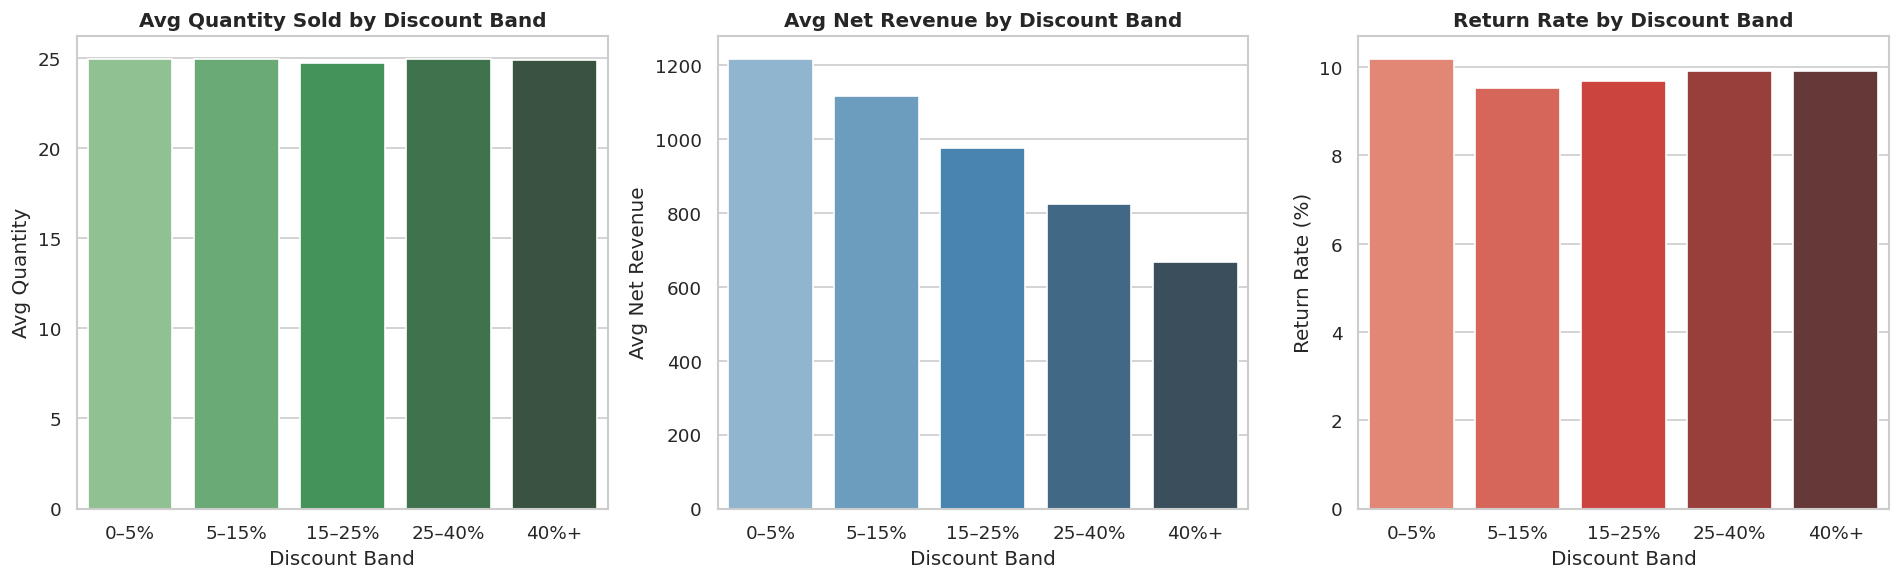

DiscountBucket  AvgQuantity  AvgNetRevenue  ReturnRate  OrderCount
          0–5%    24.928393    1217.621299   10.193895        5209
         5–15%    24.963495    1117.789838    9.525330        9396
        15–25%    24.728999     976.592303    9.683920        9428
        25–40%    24.940778     823.353648    9.914697       14302
          40%+    24.897857     667.343930    9.924090        8958


In [55]:
bins = [0, 0.05, 0.15, 0.25, 0.40, 1.0]
labels = ["0–5%", "5–15%", "15–25%", "25–40%", "40%+"]
df["DiscountBucket"] = pd.cut(
    df["Discount"], bins=bins, labels=labels, include_lowest=True
)

disc_agg = (
    df.groupby("DiscountBucket", observed=True)
    .agg(
        AvgQuantity=("Quantity", "mean"),
        AvgNetRevenue=("NetRevenue", "mean"),
        ReturnRate=("IsReturned", "mean"),
        OrderCount=("InvoiceNo", "count"),
    )
    .reset_index()
)
disc_agg["ReturnRate"] = disc_agg["ReturnRate"] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(
    data=disc_agg, x="DiscountBucket", y="AvgQuantity", ax=axes[0], palette="Greens_d"
)
axes[0].set_title("Avg Quantity Sold by Discount Band", fontweight="bold")
axes[0].set_xlabel("Discount Band")
axes[0].set_ylabel("Avg Quantity")

sns.barplot(
    data=disc_agg, x="DiscountBucket", y="AvgNetRevenue", ax=axes[1], palette="Blues_d"
)
axes[1].set_title("Avg Net Revenue by Discount Band", fontweight="bold")
axes[1].set_xlabel("Discount Band")
axes[1].set_ylabel("Avg Net Revenue")

sns.barplot(
    data=disc_agg, x="DiscountBucket", y="ReturnRate", ax=axes[2], palette="Reds_d"
)
axes[2].set_title("Return Rate by Discount Band", fontweight="bold")
axes[2].set_xlabel("Discount Band")
axes[2].set_ylabel("Return Rate (%)")

plt.tight_layout()
plt.savefig("/content/insight2_discount_analysis.png", bbox_inches="tight")
plt.show()
print(disc_agg.to_string(index=False))


Insight: Discounts aren't improving sales or reducing return rate but revenue is dropping for each larger discount band. At the highest discount band (40%+) revenue drops by almost half. The suggestion here would be to re-assess discount bands, possibly reduce the bigger discounts.

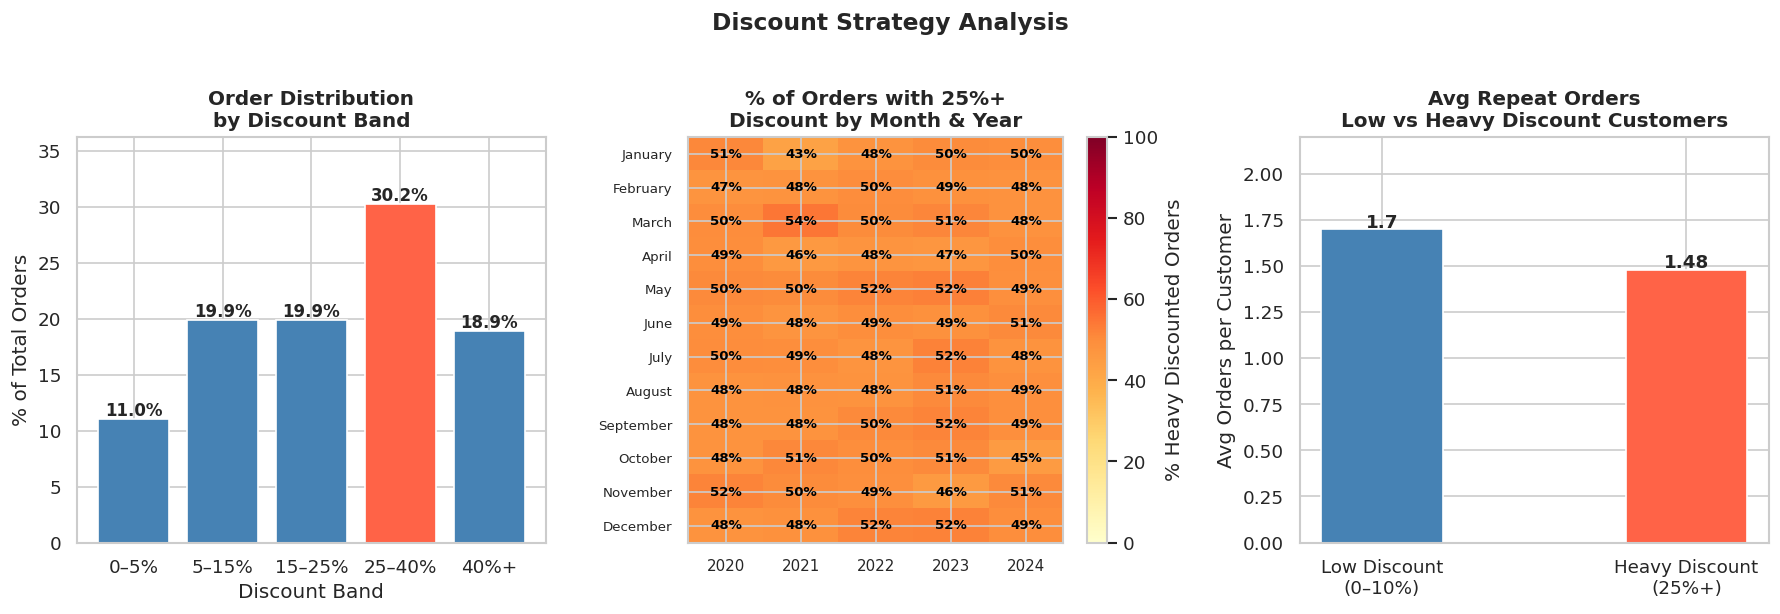

In [56]:
# Compute discount cost per year
df["DiscountAmount"] = df["GrossRevenue"] * df["Discount"]
discount_cost = (
    df.groupby("Year")["DiscountAmount"].sum().round(0).astype(int).reset_index()
)

# Compute discount buckets
bins = [0, 0.05, 0.15, 0.25, 0.40, 1.0]
labels = ["0–5%", "5–15%", "15–25%", "25–40%", "40%+"]
df["DiscountBucket"] = pd.cut(
    df["Discount"], bins=bins, labels=labels, include_lowest=True
)

disc_agg = (
    df.groupby("DiscountBucket", observed=True)
    .agg(
        AvgQuantity=("Quantity", "mean"),
        AvgNetRevenue=("NetRevenue", "mean"),
        ReturnRate=("IsReturned", "mean"),
        OrderCount=("InvoiceNo", "count"),
    )
    .reset_index()
)
disc_agg["ReturnRate"] = disc_agg["ReturnRate"] * 100
disc_agg["PctOrders"] = (
    disc_agg["OrderCount"] / disc_agg["OrderCount"].sum() * 100
).round(1)

discount_compare = pd.DataFrame(
    {
        "Customer Type": ["Low Discount\n(0–10%)", "Heavy Discount\n(25%+)"],
        "AvgOrders": [1.70, 1.48],
    }
)

# Heavy discount share per category
category_discount_band = (
    df.groupby(["Category", "DiscountBucket"], observed=True)["InvoiceNo"]
    .count()
    .unstack(fill_value=0)
)
category_discount_band = (
    category_discount_band.div(category_discount_band.sum(axis=1), axis=0) * 100
)
category_discount_band = category_discount_band.round(1)
category_discount_heavy = category_discount_band[["25–40%", "40%+"]].copy()
category_discount_heavy["Total Heavy"] = category_discount_heavy.sum(axis=1)
category_discount_heavy = category_discount_heavy.sort_values(
    "Total Heavy", ascending=True
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Order Distribution by Discount Band
colors_band = ["steelblue" if p < 25 else "tomato" for p in disc_agg["PctOrders"]]
bars = axes[0].bar(disc_agg["DiscountBucket"], disc_agg["PctOrders"], color=colors_band)
for bar, val in zip(bars, disc_agg["PctOrders"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
axes[0].set_title("Order Distribution\nby Discount Band", fontweight="bold")
axes[0].set_xlabel("Discount Band")
axes[0].set_ylabel("% of Total Orders")
axes[0].set_ylim(0, disc_agg["PctOrders"].max() * 1.2)

# Discount presence heatmap — % of orders discounted per month per year
discount_heatmap = (
    df.groupby(["Year", "Month"])
    .apply(lambda x: (x["Discount"] > 0.25).mean() * 100)
    .round(1)
    .unstack(level=0)
)

# Discount presence heatmap
discount_heatmap = (
    df.groupby(["Year", "Month"])
    .apply(lambda x: (x["Discount"] > 0.25).mean() * 100)
    .round(1)
    .unstack(level=0)
)
discount_heatmap = discount_heatmap.drop(columns=[2025], errors="ignore")

im = axes[1].imshow(
    discount_heatmap.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100
)

axes[1].set_xticks(range(len(discount_heatmap.columns)))
axes[1].set_xticklabels(discount_heatmap.columns, fontsize=9)
axes[1].set_yticks(range(len(discount_heatmap.index)))
axes[1].set_yticklabels([MONTH_NAMES[m] for m in discount_heatmap.index], fontsize=8)

for i in range(len(discount_heatmap.index)):
    for j in range(len(discount_heatmap.columns)):
        axes[1].text(
            j,
            i,
            f"{discount_heatmap.values[i,j]:.0f}%",
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            fontweight="bold",
        )

plt.colorbar(im, ax=axes[1], label="% Heavy Discounted Orders")
axes[1].set_title("% of Orders with 25%+\nDiscount by Month & Year", fontweight="bold")

# Panel 3: Avg Repeat Orders
bars = axes[2].bar(
    discount_compare["Customer Type"],
    discount_compare["AvgOrders"],
    color=["steelblue", "tomato"],
    width=0.4,
)
for bar, val in zip(bars, discount_compare["AvgOrders"]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
axes[2].set_title(
    "Avg Repeat Orders\nLow vs Heavy Discount Customers", fontweight="bold"
)
axes[2].set_ylabel("Avg Orders per Customer")
axes[2].set_ylim(0, 2.2)

plt.suptitle("Discount Strategy Analysis", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/content/insight_discount_deep.png", bbox_inches="tight")
plt.show()

Insight: Discounts have become par for the course, store has trained its customers to always expect heavy discounts and its not drawing or retaining customers.

Discount vs Net Revenue Scatter

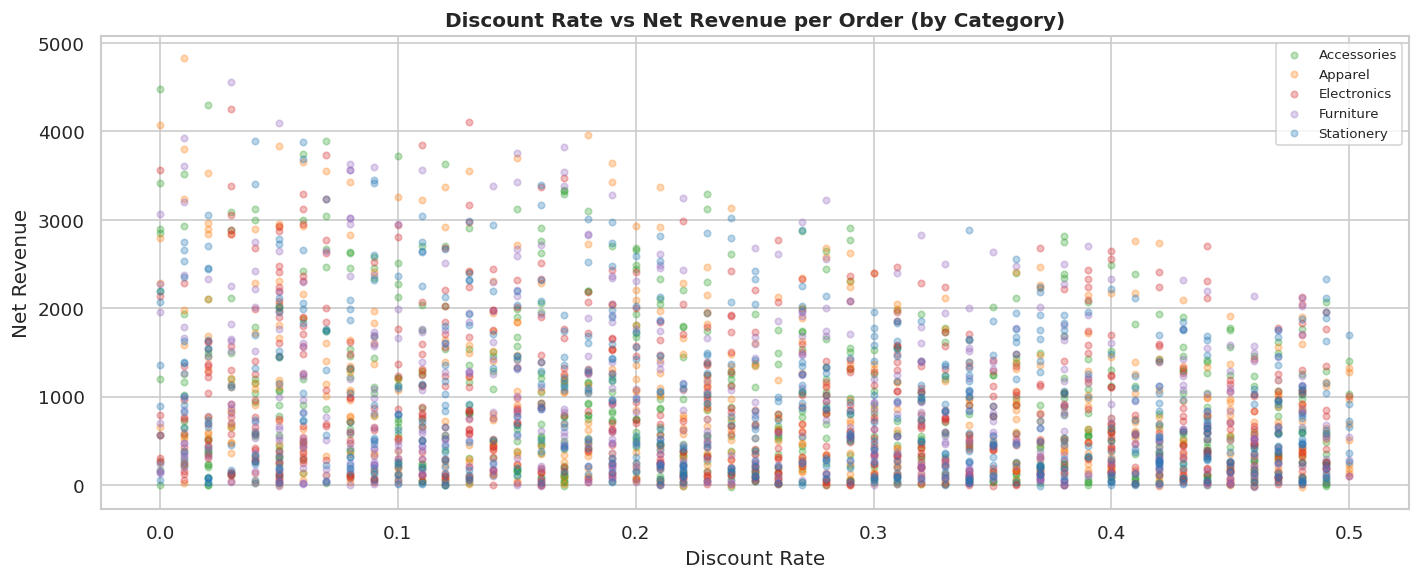

In [57]:
sample = df.sample(min(3000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 5))
categories = sample["Category"].unique()
palette = dict(zip(categories, sns.color_palette("tab10", len(categories))))

for cat, grp in sample.groupby("Category"):
    ax.scatter(
        grp["Discount"],
        grp["NetRevenue"],
        alpha=0.3,
        s=15,
        label=cat,
        color=palette[cat],
    )

ax.set_title("Discount Rate vs Net Revenue per Order (by Category)", fontweight="bold")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Net Revenue")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("/content/insight2_discount_scatter.png", bbox_inches="tight")
plt.show()

Insight: Skip this graph. Too noisy to draw any conclusions.

EDA: Return Rate Analysis

Return Rate by Category

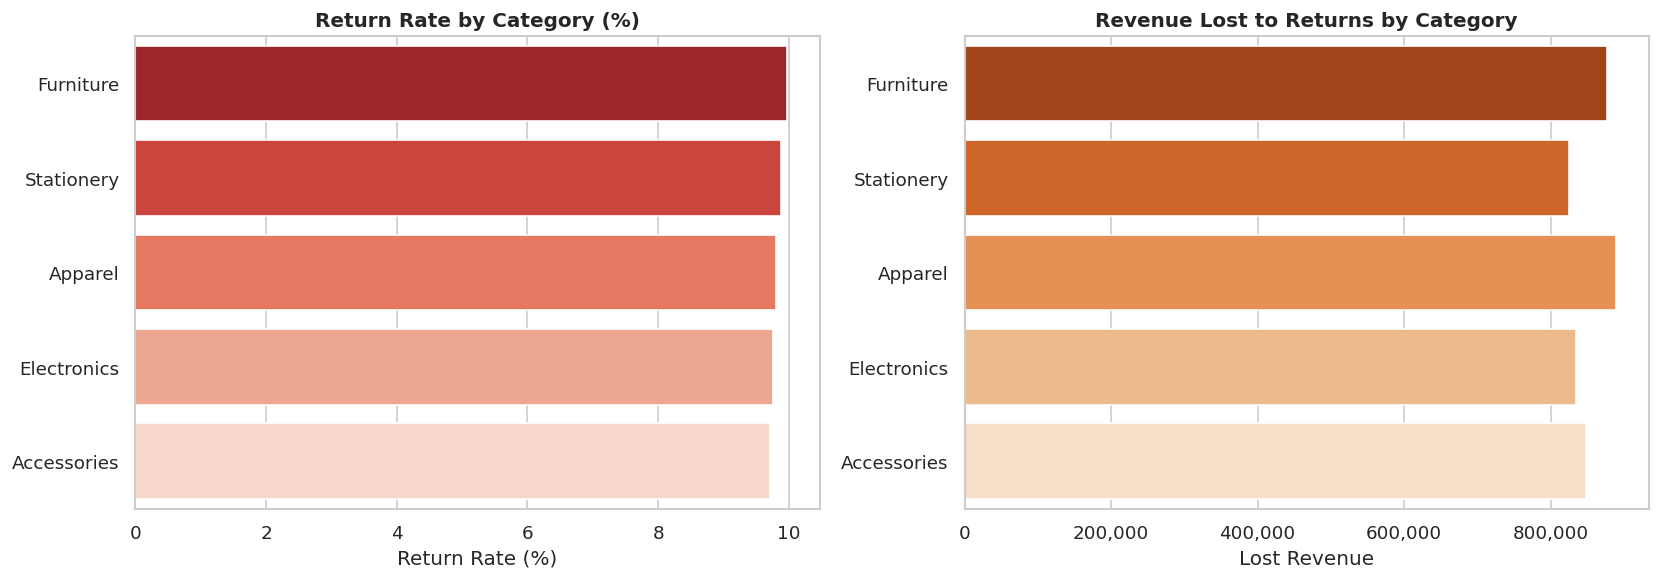

   Category  ReturnRate  ReturnedRevenue  TotalOrders
  Furniture    9.971807      876647.7050         9577
 Stationery    9.877197      825207.2961         9446
    Apparel    9.804966      889400.9609         9383
Electronics    9.752995      834825.3904         9433
Accessories    9.710176      848312.0241         9454


In [58]:
ret_cat = (
    df.groupby("Category")
    .agg(
        ReturnRate=("IsReturned", "mean"),
        ReturnedRevenue=(
            "NetRevenue",
            lambda x: x[df.loc[x.index, "IsReturned"] == 1].sum(),
        ),
        TotalOrders=("InvoiceNo", "count"),
    )
    .reset_index()
    .sort_values("ReturnRate", ascending=False)
)
ret_cat["ReturnRate"] = ret_cat["ReturnRate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=ret_cat, x="ReturnRate", y="Category", ax=axes[0], palette="Reds_r")
axes[0].set_title("Return Rate by Category (%)", fontweight="bold")
axes[0].set_xlabel("Return Rate (%)")
axes[0].set_ylabel("")

sns.barplot(
    data=ret_cat, x="ReturnedRevenue", y="Category", ax=axes[1], palette="Oranges_r"
)
axes[1].set_title("Revenue Lost to Returns by Category", fontweight="bold")
axes[1].set_xlabel("Lost Revenue")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("/content/insight3_returns_category.png", bbox_inches="tight")
plt.show()
print(ret_cat.to_string(index=False))

Insight: Revenue rates across categories are evenly distributed, however the overall return rate is around 10%, meaning 1 in 10 items purchased are returned, leading to 4M+ is lost revenue across all categories over the course of 5 years. This is a striking business stat.

Top 10 most returned items

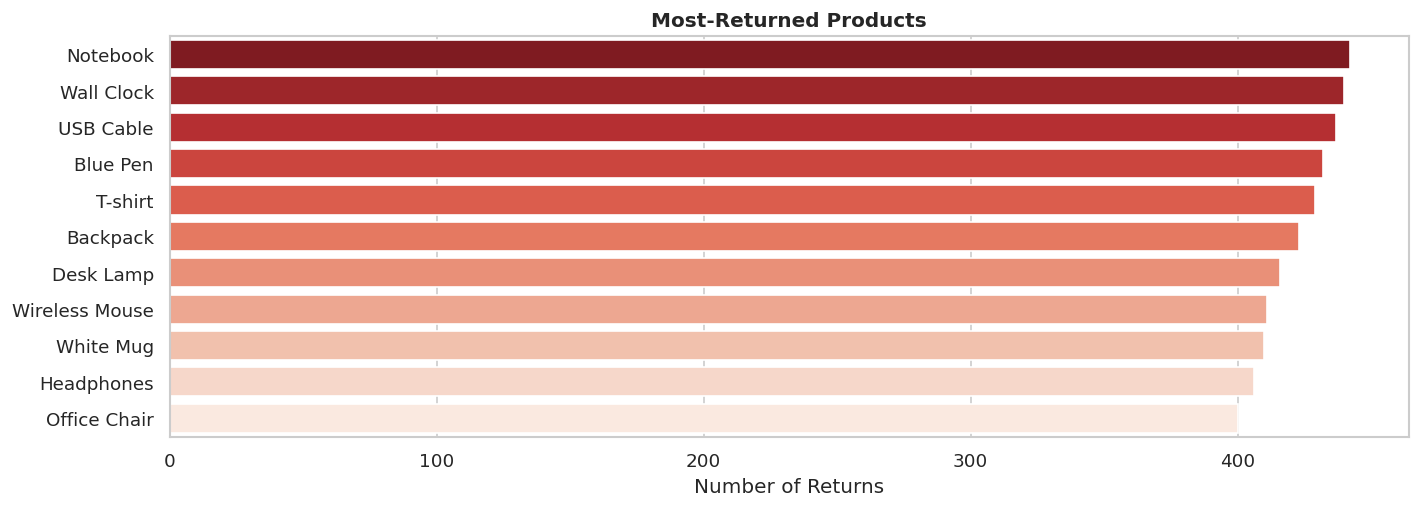

   Description  Returns  RevenueLost
      Notebook      442  397715.4668
    Wall Clock      440  392541.0122
     USB Cable      437  412405.2235
      Blue Pen      432  402913.7955
       T-shirt      429  386618.6788
      Backpack      423  400920.1680
     Desk Lamp      416  375525.0582
Wireless Mouse      411  404440.8156
     White Mug      410  389536.7435
    Headphones      406  356179.9611
  Office Chair      400  355596.4533


In [59]:
ret_prod = (
    df[df["IsReturned"] == 1]
    .groupby("Description")
    .agg(Returns=("IsReturned", "sum"), RevenueLost=("NetRevenue", "sum"))
    .sort_values("Returns", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, len(ret_prod) * 0.4))

sns.barplot(data=ret_prod, x="Returns", y="Description", ax=ax, palette="Reds_r")
ax.set_title("Most-Returned Products", fontweight="bold")
ax.set_xlabel("Number of Returns")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("/content/insight3_top_returned_products.png", bbox_inches="tight")
plt.show()
print(ret_prod.to_string(index=False))


Insight: Not much difference in terms of which items get returned more. Skippable.

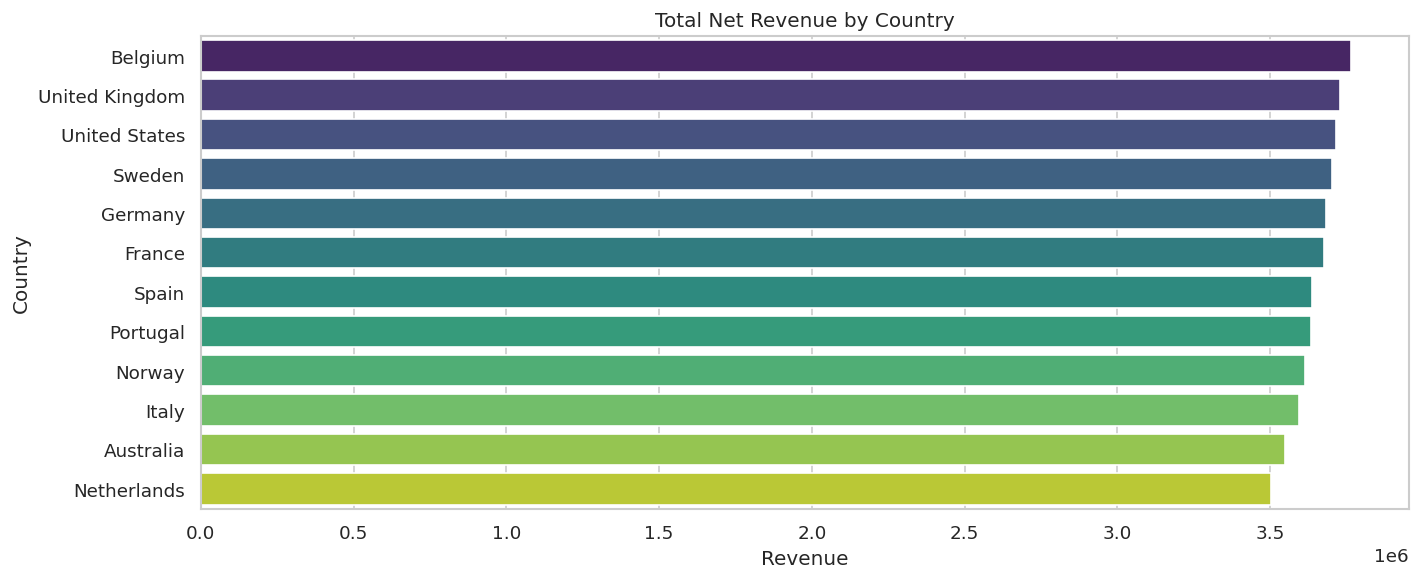

In [60]:
# Revenue by Country
country_rev = df.groupby("Country")["NetRevenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=country_rev.values, y=country_rev.index, palette="viridis")
plt.title("Total Net Revenue by Country")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


Revenue by Sales Channel

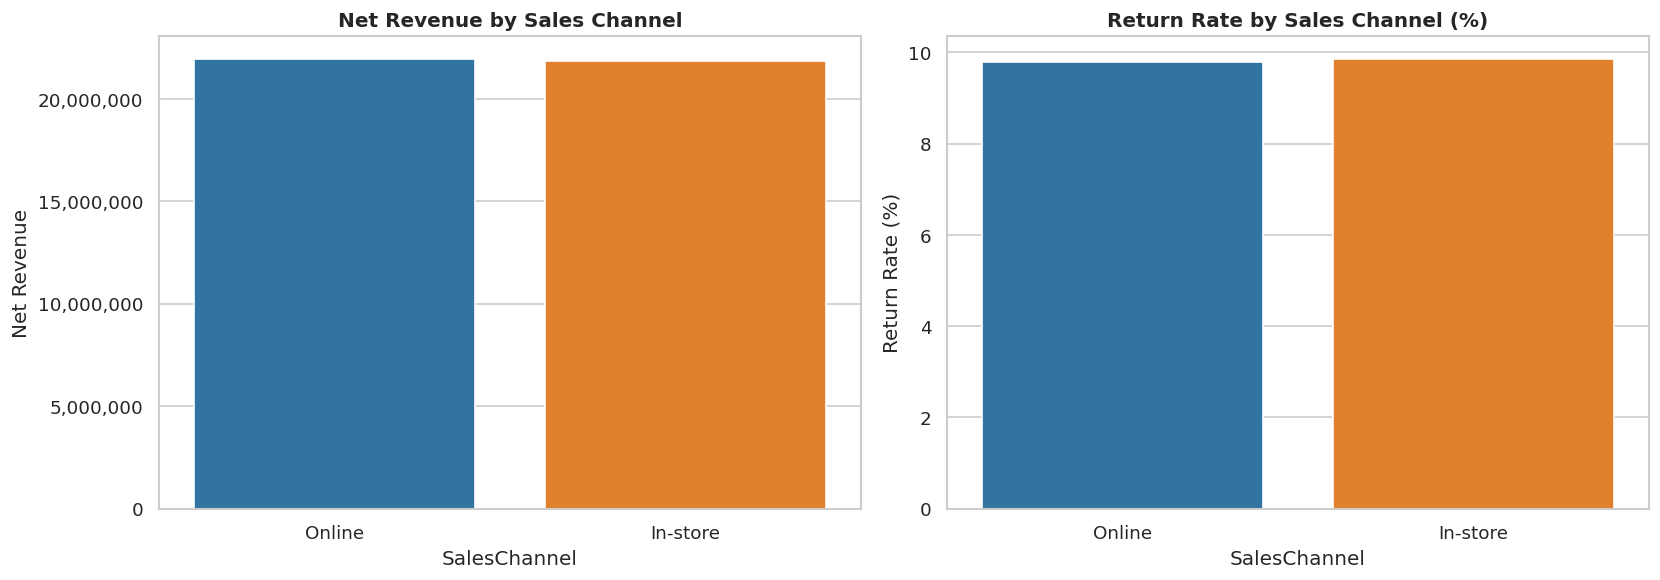

SalesChannel   NetRevenue  OrderCount  ReturnRate
      Online 2.195608e+07       23762    9.784530
    In-store 2.185024e+07       23531    9.863584


In [61]:
channel_rev = (
    df.groupby("SalesChannel")
    .agg(
        NetRevenue=("NetRevenue", "sum"),
        OrderCount=("InvoiceNo", "count"),
        ReturnRate=("IsReturned", "mean"),
    )
    .reset_index()
    .sort_values("NetRevenue", ascending=False)
)

channel_rev["ReturnRate"] = channel_rev["ReturnRate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=channel_rev, x="SalesChannel", y="NetRevenue", ax=axes[0], palette="tab10"
)
axes[0].set_title("Net Revenue by Sales Channel", fontweight="bold")
axes[0].set_ylabel("Net Revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

sns.barplot(
    data=channel_rev, x="SalesChannel", y="ReturnRate", ax=axes[1], palette="tab10"
)
axes[1].set_title("Return Rate by Sales Channel (%)", fontweight="bold")
axes[1].set_ylabel("Return Rate (%)")

plt.tight_layout()
plt.savefig("/content/insight4_channel.png", bbox_inches="tight")
plt.show()
print(channel_rev.to_string(index=False))


Insight: Nothing to draw from this. Identical sales both online and in-store.

Customer Segmentation: RFM Analysis

In [62]:
df_rfm = df.dropna(subset=["CustomerID"]).copy()
snapshot_date = df_rfm["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_rfm.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("NetRevenue", "sum"),
    )
    .reset_index()
)

rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4]
).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
)
rfm["RFM_Total"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]


def segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 2:
        return "Loyal Customers"
    elif r >= 3 and f == 1:
        return "Recent Customers"
    elif r == 2 and f >= 2:
        return "At Risk"
    elif r <= 2 and f >= 3:
        return "Cant Lose Them"
    elif r == 1 and f == 1:
        return "Lost"
    else:
        return "Needs Attention"


rfm["Segment"] = rfm.apply(segment, axis=1)
print(rfm["Segment"].value_counts())
rfm.head()

Segment
Loyal Customers     7493
At Risk             6517
Champions           6286
Needs Attention     4991
Recent Customers    3920
Cant Lose Them      3594
Lost                2588
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,10001.0,742,1,1447.5534,3,1,3,313,7,Recent Customers
1,10003.0,1842,1,354.6485,1,1,2,112,4,Lost
2,10005.0,251,2,2297.0230,4,4,4,444,12,Champions
3,10008.0,145,1,26.0280,4,1,1,411,6,Recent Customers
4,10009.0,1826,1,439.9504,1,1,2,112,4,Lost


RFM Visualization

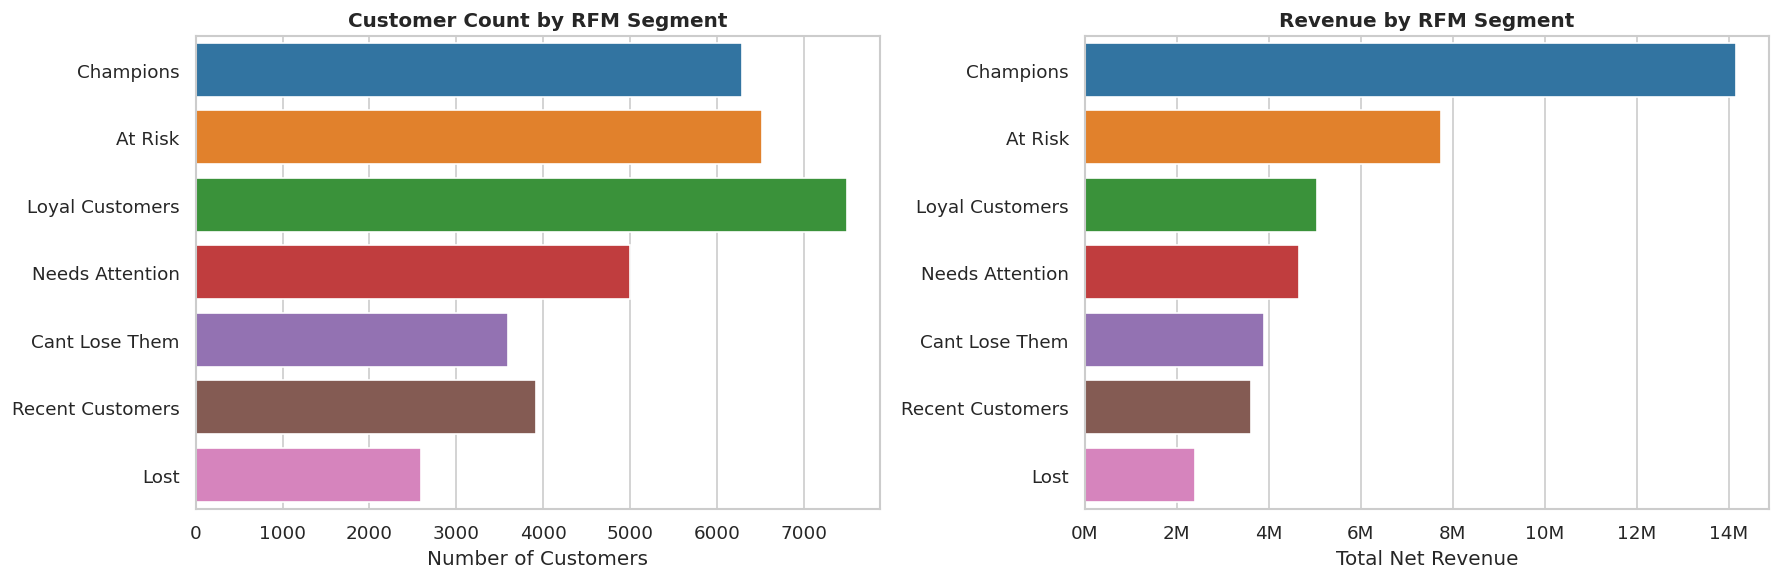

         Segment  CustomerCount  TotalRevenue
       Champions           6286  1.416615e+07
         At Risk           6517  7.744922e+06
 Loyal Customers           7493  5.046653e+06
 Needs Attention           4991  4.660879e+06
  Cant Lose Them           3594  3.891602e+06
Recent Customers           3920  3.624209e+06
            Lost           2588  2.397424e+06


In [63]:
seg_counts = rfm["Segment"].value_counts().reset_index()
seg_counts.columns = ["Segment", "CustomerCount"]

seg_revenue = rfm.groupby("Segment")["Monetary"].sum().reset_index()
seg_revenue.columns = ["Segment", "TotalRevenue"]
seg_summary = seg_counts.merge(seg_revenue, on="Segment").sort_values(
    "TotalRevenue", ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=seg_summary, x="CustomerCount", y="Segment", ax=axes[0], palette="tab10"
)
axes[0].set_title("Customer Count by RFM Segment", fontweight="bold")
axes[0].set_xlabel("Number of Customers")
axes[0].set_ylabel("")

sns.barplot(
    data=seg_summary, x="TotalRevenue", y="Segment", ax=axes[1], palette="tab10"
)
axes[1].set_title("Revenue by RFM Segment", fontweight="bold")
axes[1].set_xlabel("Total Net Revenue")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

plt.tight_layout()
plt.savefig("/content/insight5_rfm_segments.png", bbox_inches="tight")
plt.show()
print(seg_summary.to_string(index=False))

Insight:

*   Champions generate the highest revenue at 14M+
*   At Risk customers generate the next highest because they used to be Champions but at risk of becoming Lost. They are the highest priority to sustain.



MACHINE LEARNING

In [28]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [64]:
# Prepare Monthly Demand per Product
monthly_demand = (
    df.groupby(["Description", "YearMonth"])["Quantity"].sum().reset_index()
)
monthly_demand["ds"] = monthly_demand["YearMonth"].dt.to_timestamp()
monthly_demand = monthly_demand.rename(columns={"Quantity": "y"})
monthly_demand = monthly_demand[monthly_demand["ds"] < monthly_demand["ds"].max()]

print(f'Products: {monthly_demand["Description"].nunique()}')
print(
    f'Months per product: {monthly_demand.groupby("Description")["ds"].count().values[0]}'
)
monthly_demand.head()


Products: 11
Months per product: 68


,Description,YearMonth,y,ds
0,Backpack,2020-01,1673,2020-01-01
1,Backpack,2020-02,1497,2020-02-01
2,Backpack,2020-03,1658,2020-03-01
3,Backpack,2020-04,1662,2020-04-01
4,Backpack,2020-05,1584,2020-05-01


In [65]:
# Train Prophet per Product
prophet_models = {}
prophet_metrics = {}

for product in monthly_demand["Description"].unique():
    pdf = monthly_demand[monthly_demand["Description"] == product][
        ["ds", "y"]
    ].reset_index(drop=True)

    train_p = pdf.iloc[:-3]
    test_p = pdf.iloc[-3:]

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
    )
    m.fit(train_p)

    forecast = m.predict(test_p[["ds"]])
    preds = forecast["yhat"].clip(lower=0).values
    actuals = test_p["y"].values

    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))

    prophet_models[product] = m
    prophet_metrics[product] = {"MAE": round(mae, 1), "RMSE": round(rmse, 1)}

metrics_df = (
    pd.DataFrame(prophet_metrics)
    .T.reset_index()
    .rename(columns={"index": "Description"})
)
print(metrics_df.sort_values("MAE").to_string(index=False))
print(f'\nAvg MAE:  {metrics_df["MAE"].mean():.1f}')
print(f'Avg RMSE: {metrics_df["RMSE"].mean():.1f}')


   Description   MAE  RMSE
      Blue Pen  61.1  66.0
  Office Chair 115.8 142.8
       T-shirt 134.3 162.7
     USB Cable 140.3 152.0
    Wall Clock 171.2 210.7
     White Mug 201.6 237.3
      Backpack 203.8 288.8
     Desk Lamp 219.5 259.9
Wireless Mouse 230.5 289.3
      Notebook 250.1 321.0
    Headphones 311.5 342.6

Avg MAE:  185.4
Avg RMSE: 224.8


In [66]:
# Compute Volatility
def compute_volatility(df):
    monthly = df.groupby(["Description", "YearMonth"])["Quantity"].sum().reset_index()

    vol = (
        monthly.groupby("Description")["Quantity"]
        .agg(StdDev="std", AvgDemand="mean")
        .fillna(0)
        .reset_index()
    )

    vol["CV"] = (vol["StdDev"] / vol["AvgDemand"]).fillna(0)

    cv_min, cv_max = vol["CV"].min(), vol["CV"].max()
    vol["LowerBuffer"] = 0.05 + 0.15 * (vol["CV"] - cv_min) / (cv_max - cv_min + 1e-9)
    vol["UpperBuffer"] = 0.10 + 0.25 * (vol["CV"] - cv_min) / (cv_max - cv_min + 1e-9)

    return vol[["Description", "CV", "LowerBuffer", "UpperBuffer"]]


volatility_df = compute_volatility(df)
print(volatility_df.to_string(index=False))


   Description       CV  LowerBuffer  UpperBuffer
      Backpack 0.175006     0.136948     0.244913
      Blue Pen 0.165957     0.102553     0.187588
     Desk Lamp 0.175926     0.140445     0.250742
    Headphones 0.187009     0.182573     0.320955
      Notebook 0.171497     0.123610     0.222683
  Office Chair 0.175503     0.138840     0.248067
       T-shirt 0.170239     0.118828     0.214713
     USB Cable 0.152132     0.050000     0.100000
    Wall Clock 0.171272     0.122755     0.221259
     White Mug 0.183024     0.167427     0.295711
Wireless Mouse 0.191593     0.200000     0.350000


In [67]:
# Forecast Function
def forecast_restock_prophet(month: int, year: int = 2025):
    assert 1 <= month <= 12, "Month must be between 1 and 12"

    target_date = pd.Timestamp(f"{year}-{month:02d}-01")
    results = []

    for product, m in prophet_models.items():
        future = pd.DataFrame({"ds": [target_date]})
        forecast = m.predict(future)
        qty = max(0, round(forecast["yhat"].values[0]))
        results.append({"Description": product, "RecommendedRestock": qty})

    restock_df = pd.DataFrame(results).sort_values("Description", ascending=False)

    restock_df = restock_df.merge(
        volatility_df[["Description", "CV", "LowerBuffer", "UpperBuffer"]],
        on="Description",
        how="left",
    )
    restock_df["MinRestock"] = (
        restock_df["RecommendedRestock"] * (1 - restock_df["LowerBuffer"])
    ).astype(int)
    restock_df["MaxRestock"] = (
        restock_df["RecommendedRestock"] * (1 + restock_df["UpperBuffer"])
    ).astype(int)

    plot_restock(restock_df, month, year)
    print(
        restock_df[
            ["Description", "MinRestock", "RecommendedRestock", "MaxRestock", "CV"]
        ].to_string(index=False)
    )


print("forecast_restock_prophet() ready.")


forecast_restock_prophet() ready.


In [68]:
def plot_restock(restock_df, month, year):
    restock_df = restock_df.sort_values("Description", ascending=False)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(
        restock_df["Description"],
        restock_df["RecommendedRestock"],
        xerr=[
            restock_df["RecommendedRestock"] - restock_df["MinRestock"],
            restock_df["MaxRestock"] - restock_df["RecommendedRestock"],
        ],
        color="steelblue",
        capsize=5,
        error_kw={"ecolor": "black", "linewidth": 1.5},
    )

    for _, row in restock_df.iterrows():
        idx = list(restock_df["Description"]).index(row["Description"])
        ax.text(
            row["RecommendedRestock"] / 2,
            idx,
            f"{row['RecommendedRestock']:,}",
            va="center",
            ha="center",
            fontsize=9,
            color="white",
            fontweight="bold",
        )
        ax.text(
            row["MaxRestock"] + 20,
            idx,
            f"{row['MinRestock']:,} – {row['MaxRestock']:,}",
            va="center",
            fontsize=8,
            color="dimgray",
        )

    ax.set_title(
        f"Recommended Restock : {MONTH_NAMES[month]} {year}",
        fontweight="bold",
        fontsize=13,
    )
    ax.set_xlabel("Units to Restock")
    ax.set_ylabel("")
    ax.set_xlim(0, restock_df["MaxRestock"].max() * 1.3)
    plt.tight_layout()
    plt.savefig(
        f"/content/ml_restock_{MONTH_NAMES[month].lower()}_{year}.png",
        bbox_inches="tight",
    )
    plt.show()


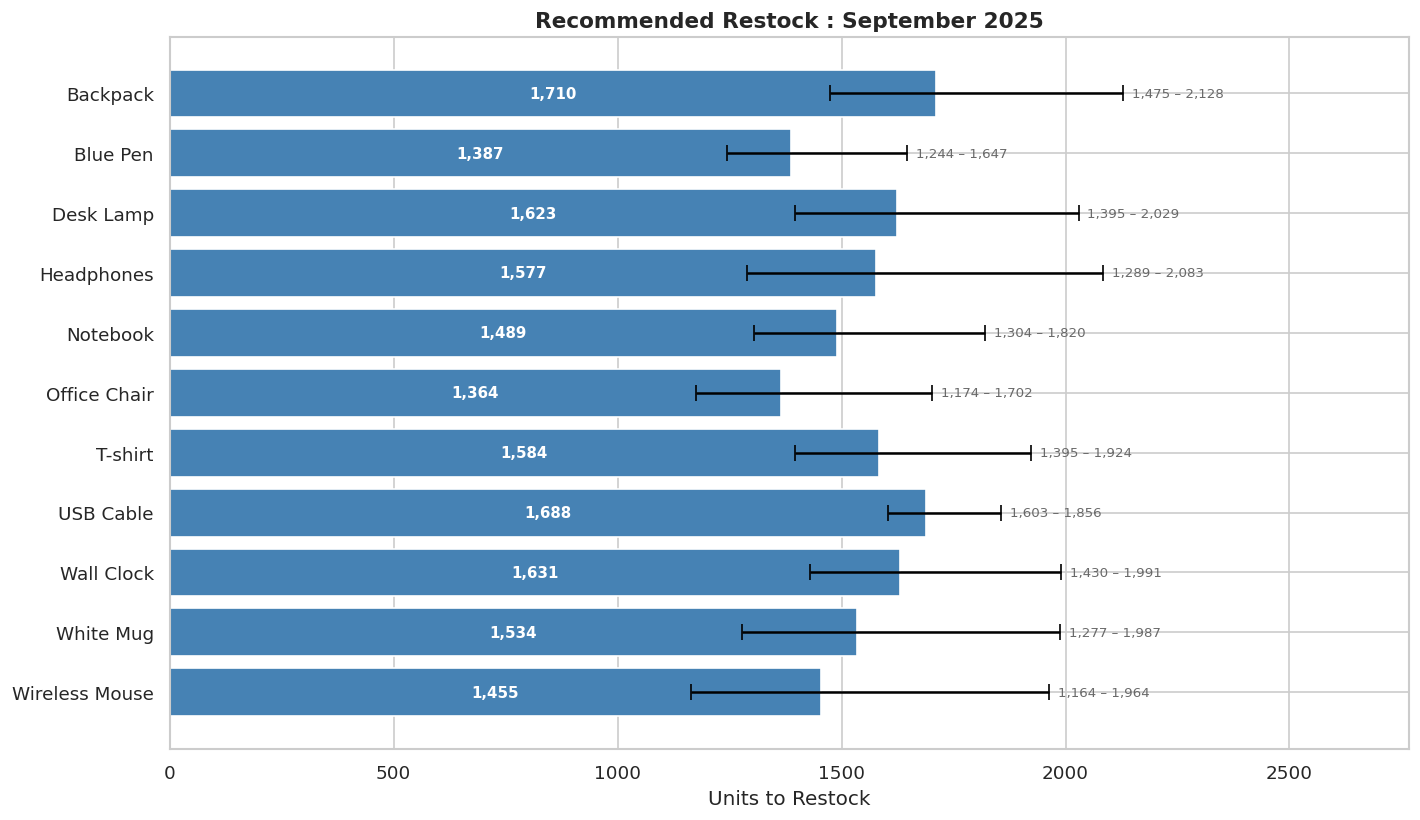

   Description  MinRestock  RecommendedRestock  MaxRestock       CV
Wireless Mouse        1164                1455        1964 0.191593
     White Mug        1277                1534        1987 0.183024
    Wall Clock        1430                1631        1991 0.171272
     USB Cable        1603                1688        1856 0.152132
       T-shirt        1395                1584        1924 0.170239
  Office Chair        1174                1364        1702 0.175503
      Notebook        1304                1489        1820 0.171497
    Headphones        1289                1577        2083 0.187009
     Desk Lamp        1395                1623        2029 0.175926
      Blue Pen        1244                1387        1647 0.165957
      Backpack        1475                1710        2128 0.175006


In [69]:
# Run Inference
forecast_restock_prophet(month=9, year=2025)

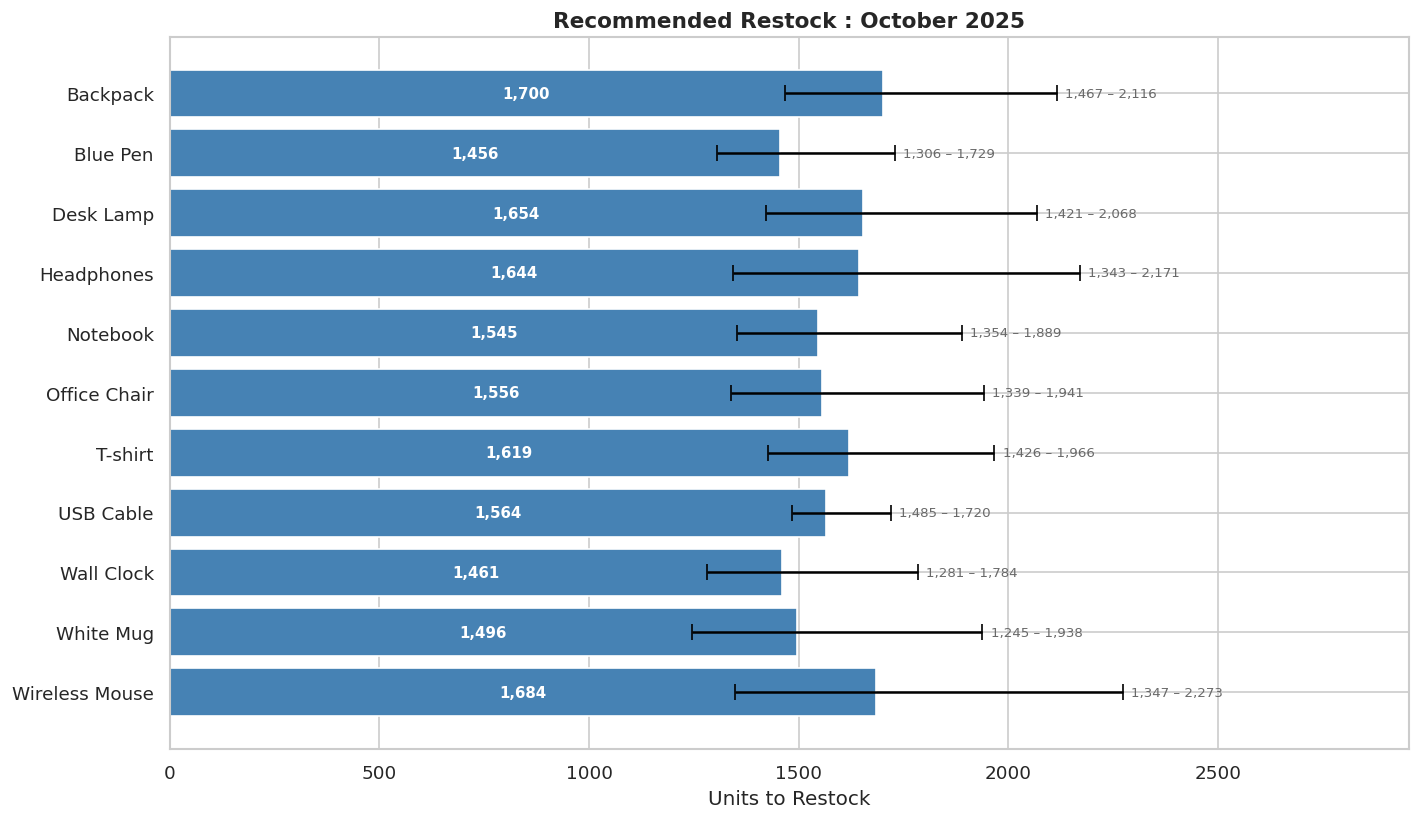

   Description  MinRestock  RecommendedRestock  MaxRestock       CV
Wireless Mouse        1347                1684        2273 0.191593
     White Mug        1245                1496        1938 0.183024
    Wall Clock        1281                1461        1784 0.171272
     USB Cable        1485                1564        1720 0.152132
       T-shirt        1426                1619        1966 0.170239
  Office Chair        1339                1556        1941 0.175503
      Notebook        1354                1545        1889 0.171497
    Headphones        1343                1644        2171 0.187009
     Desk Lamp        1421                1654        2068 0.175926
      Blue Pen        1306                1456        1729 0.165957
      Backpack        1467                1700        2116 0.175006


In [70]:
forecast_restock_prophet(month=10, year=2025)

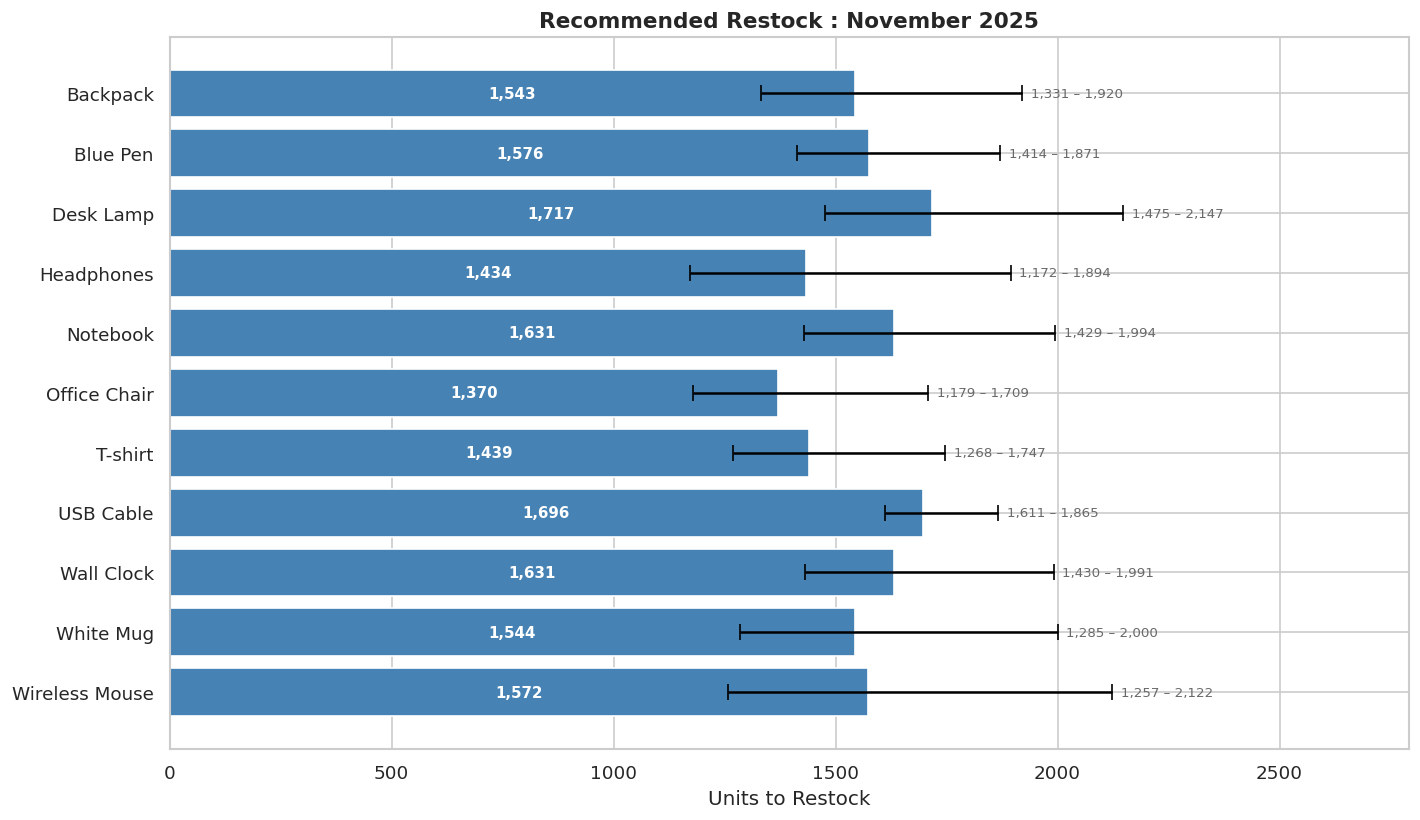

   Description  MinRestock  RecommendedRestock  MaxRestock       CV
Wireless Mouse        1257                1572        2122 0.191593
     White Mug        1285                1544        2000 0.183024
    Wall Clock        1430                1631        1991 0.171272
     USB Cable        1611                1696        1865 0.152132
       T-shirt        1268                1439        1747 0.170239
  Office Chair        1179                1370        1709 0.175503
      Notebook        1429                1631        1994 0.171497
    Headphones        1172                1434        1894 0.187009
     Desk Lamp        1475                1717        2147 0.175926
      Blue Pen        1414                1576        1871 0.165957
      Backpack        1331                1543        1920 0.175006


In [71]:
forecast_restock_prophet(month=11, year=2025)